In [1]:
import numpy as np
from scipy.optimize import fsolve
L = 47
Ga = 5000
Gs = 10000
da = 6
ds = 3

Tb = 5

Js = np.pi/2*(ds/2)**4
Ja = np.pi/2*((da/2)**4-(ds/2)**4)

def equations(vars):
    TA,TS = vars
    eq1 = TA+TS-Tb
    eq2 = TA*L/(Ja*Ga) - TS*L/(Js*Gs)
    return [eq1,eq2]
ig = [1,1]
ans = fsolve(equations,ig)
phi = ans[0]*L/(Ja*Ga)
print(phi)

0.00034766744286159854


In [2]:
di = 0.032
TB = 1531
TC = 424
G = 103*10**6
L = 1.199
tmax = 11*10**6

T1 = TB - TC
T2 = -TC
print(T1,T2)

def equations(d):
    J1 = np.pi/2*(d/2)**4
    eq1 = T1*d/2/J1 - tmax
    return eq1
ig = [0.1]
d1 = fsolve(equations,ig)[0]
print(d1*1000)

J2 = np.pi/2*((d1/2)**4-(di/2)**4)
J1 = np.pi/2*(d1/2)**4

phic = T2*L/(J2*G)
phib = T1*L/(J1*G)

print(phib + phic)

1107 -424
80.0279481143557
1.9422481441710835


In [3]:
d = 0.04
Gst = 75*10**9
a = 0.058
LAC = 0.4
LBC = 0.6
F = 3000

J = np.pi/2*(d/2)**4
T = F*a*2
def equations(vars):
    TA,TB = vars
    eq1 = TA + TB - T
    eq2 = TA*LAC/(J*G) - TB*LBC/(J*G)
    return [eq1,eq2]
ig = [10,10]
ans = fsolve(equations,ig)
tac = ans[0]*d/2/J
tbc = ans[1]*d/2/J
print(tac/1000000,tbc/1000000)

16.615776058793873 11.077184039195915


In [14]:
from sympy import *
G = 11e3  # ksi
G = G*1000  # psi
d = 1  # in
T = 71*12  # lb*in

J = 1/2*pi*(d/2)**4
T1 = 40*12  # lb*in
T2 = T1/4*6

phi1 = T2*30/(J*G)
phi2 = (T-T2)*10/(J*G)
phi12 = phi1 - phi2
phi3 = phi12*6/4
phi4 = T1*10/(J*G)
phiA = phi3 + phi4
(phiA/pi*180).evalf()  # 问的是°！！！


1.86861316601881

In [5]:
R1 = 0.123
R2 = 0.049
d = 0.028
Tw = 4.138

T1 = Tw
T2 = T1/R2*R1 #受力相同

J1 = np.pi/2*R1**4
J2 = np.pi/2*R2**4
J = np.pi/2*(d/2)**4

T4 = T2/R2*R1 
#同一个轴上的T一样，没有额外负载的话
#但是扭转角会随着距离发生变化
tmax = T4*d/2/J

print(T1,T2,T4,tmax/1000000)

4.138 10.387224489795917 26.074053311120363 6.049292231641991


In [6]:
d = 0.035
R1 = 0.176
R2 = 0.046
G = 74*10**9
L = 0.128
TE = 425

TM = TE/R1*R2
TU = TM/R1*R2

J = np.pi/2*(d/2)**4

theta1 = TU*L/(G*J)
theta2 = TM*L/(G*J)+theta1/R1*R2
theta3 = TE*L/(G*J)+theta2/R1*R2 
print(theta3)

0.005354089874013


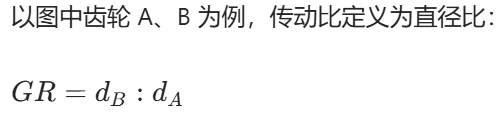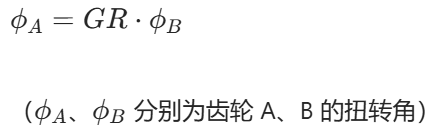

In [7]:
G = 69*10**9
d1 = 0.035
d2 = 0.059
TB = 1337
TC = 1497
L1 = 0.236
L2 = 0.613
L3 = 0.279

JAB = np.pi/2*(d1/2)**4
JBC = np.pi/2*(d2/2)**4
JCD = np.pi/2*((d2/2)**4-(d1/2)**4)

def equations(vars):
    TA,TD = vars
    eq1 = TA+TD-(TB+TC)
    eq2 = -TA*L1/(G*JAB) + (-TA+TB)*L2/(G*JBC) + (-TA+TB+TC)*L3/(G*JCD)
    return [eq1,eq2]
ig = [1000,1000]
ans = fsolve(equations,ig)
TA = ans[0]
TD = ans[1]

tau1 = TA*d1/2/JAB
tau2 = (-TA+TB)*d2/2/JBC
tau3 = (-TA+TB+TC)*d2/2/JCD
print(tau1/1000000,tau2/1000000,tau3/1000000)


72.09917262823092 18.103277641863333 63.03154714483454


In [8]:
T = 670
d = 0.03
Gst = 75*10**9
Gbr = 39*10**9
LBC = 1.6
LAB = 0.75

Jst = np.pi/2*(d/2)**4
def equations(vars):
    Tw,dbr = vars
    Jbr = np.pi/2*(dbr/2)**4
    eq1 = Tw+Tw-T
    eq2 = Tw*LAB/(Gst*Jst) + (Tw-T)*LBC/(Gbr*Jbr)
    return [eq1,eq2]
ig = [300,0.05]
ans = fsolve(equations,ig)
dbr = ans[1]
Tw = ans[0]
Jbr = np.pi/2*(dbr/2)**4

tau1 = Tw*d/2/Jst
tau2 = Tw*dbr/2/Jbr
print(dbr*1000,tau1/1000000)


42.69579440812386 63.19040703500437


In [10]:
G = 68*10**9
d = 0.053
di = d/2
TB = 1463
L = 0.151

JAB = np.pi/2*((d/2)**4-(di/2)**4)
JBC = np.pi/2*(d/2)**4

def equations(vars):
    TA,TC = vars
    eq1 = TA+TC-TB
    eq2 = TA*L/(G*JAB) + (TA-TB)*L/(G*JBC)
    return [eq1,eq2]
ig = [1000,1000]
ans = fsolve(equations,ig)
TA = ans[0]
TC = ans[1]

phi1 = TA*L/(G*JAB)
phi2 = -(TA-TB)*L/(G*JBC)
print(TA,TC,phi1,phi2)

707.9032258064517 755.0967741935483 0.002164548278060805 0.0021645482780608045


In [ ]:
a = 0.01
L = 8
theta = np.radians(97)
G = 33*10**9
tal  = 240*10**6

T1 = theta/(7.1*L/(a**4*G))

print(T1)

9.835913619073677 49.8960498960499
